In [1]:
import sys
import time

In [2]:
sys.path.append("../..")

In [3]:
from matplotlib import pyplot as plt 
from tqdm import tqdm

import numpy as np
import pandas as pd

import torch
from torchvision import transforms
from torch.nn import functional as F

from xaikd import models, datasets, utils, attributors
from xaikd.utils import metrics

from zennit.torchvision import ResNetCanonizer
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

from torch.utils.data import random_split

from scipy.stats import ortho_group
from datetime import datetime

In [4]:
device = utils.get_device()
device

'cuda'

In [5]:
dataset = datasets.construct("imagenet-butterfly")

In [6]:
ds_train = dataset.create_subset(train_split=True)
# ds_train, _ = random_split(ds_train, [0.1, 0.9])
ds_val = dataset.create_subset(train_split=False)

We have 7800 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|███████████| 7800/7800 [00:00<00:00, 894992.92it/s]


We have 300 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|█████████████| 300/300 [00:00<00:00, 556519.77it/s]


In [7]:
MODEL_NAME = "imagenet-vgg16-tv"

MAIN_LAYER = "features.9"

In [8]:
teacher = models.get_trained_model(MODEL_NAME)
utils.modify_last_layer_for_subclasses(teacher, dataset.selected_classes)

teacher.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [9]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [10]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [11]:
teacher_acc, _ = metrics.accuracy(
    teacher,
    dataloader=datasets.build_dataloader(ds_val, shuffle=False),
    num_classes=dataset.num_classes,
    device=device,
)
teacher_acc

0.9599999785423279

In [12]:
def make_attributor_for(
    model,
    input_statistics,
    gamma,
    epsilon,
):
    input_transform = transforms.Normalize(*input_statistics)

    low, high = input_transform(torch.tensor([[[[[0.0]]] * 3], [[[[1.0]]] * 3]]))

    if isinstance(model, models.resnet.resnet.ResNet):
        canonizers = [ResNetCanonizer()]
    else:
        canonizers = []

    print(f"Instantiating EpsilonGammaBox(gamma={gamma}, eps={epsilon})")

    composite = EpsilonGammaBox(low=low, high=high, canonizers=canonizers, gamma=gamma, epsilon=epsilon)

    attributor = Gradient(
        model=model, 
        composite=composite
    )

    return attributor


    
def extract_activation_context(
    model,
    layer,
    dataset,
    data_loader,
    logit_modifier,
    rng,
    gamma=0.25,
    eps=1e-6,
    device="cpu",
    number_of_selected_spatial_locations=20,
    verbose=False
):
    arr_act = []
    arr_ctx = []

    
    with make_attributor_for(model, dataset.input_statistics, gamma=gamma, epsilon=eps) as attributor:
        for batch in tqdm(data_loader):
            x, y = batch
            x = x.to(device)

            try:
                module, hook = utils.interceptor.attach_hook_intercept_layer_output(
                    model, layer, should_retain_grad=True
                )

                _ = attributor.forward(x, lambda logits: logit_modifier(logits, y))

                act = utils.interceptor.get_output(module)
                rel = act.grad
                

                output_dimensions = act.shape[1:]
                # print("output.dimension", output_dimensions)
                # todo: check this with Gregoire again!
                ctx = torch.where(
                    act.abs() > 0, 
                    rel / act, 
                    0
                )

                np.testing.assert_allclose(
                    (act * ctx).detach().cpu().numpy(), 
                    (rel * (act.abs() > 0)).detach().cpu().numpy(),
                    atol=1e-6
                )

                assert ctx.shape == act.shape

                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                if len(act.shape) == 2:
                    act = act[:, :, None, None]
                    ctx = ctx[:, :, None, None]

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

            finally:
                hook.remove()
    if verbose:
        print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx


GAMMA = 0.25

def get_act_ctx(model, dataset, layer, gamma, eps=1e-6, verbose=False):

    logit_modifier = attributors.WinningClassOneHotEvidence(num_classes=len(dataset.selected_classes))

    rng = np.random.default_rng(seed=1)

    dl = datasets.build_dataloader(
        ds_train,
        shuffle=False
    )
    return extract_activation_context(
        model=model,
        layer=layer,
        dataset=dataset,
        data_loader=dl,
        logit_modifier=logit_modifier,
        rng=rng,
        device=device,
        gamma=gamma,
        eps=eps,
        verbose=verbose,
    )


_arr_act, _arr_ctx = get_act_ctx(
    teacher,
    dataset,
    gamma=GAMMA,
    layer=MAIN_LAYER, 
    verbose=False
)

Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


100%|████████████████████████████████████████████████████████| 122/122 [02:43<00:00,  1.34s/it]


In [13]:
class BasisTransform:
    def rank_k_encoder(self, k: int):
        raise
    
    def rank_k_decoder(self, k: int):
        raise
        
    def get_hook_rank_k_transformation(self, k, device):
        
        mat_enc = self.rank_k_encoder(k)
        mat_dec = self.rank_k_decoder(k)

        # X @ U @ U.T
        mat = torch.from_numpy(mat_enc @ mat_dec)

        mat = mat.unsqueeze(2).unsqueeze(3).to(device)
        mean = torch.from_numpy(self.mean).reshape(1, -1, 1, 1).to(device)
        
        def hook_func(module, inp, out):
            return F.conv2d(
                out - mean, 
                mat
            ) + mean

        return hook_func
    
class PCA(BasisTransform):
    def __init__(self, model, layer, arr_act, arr_ctx, centering=False):
        self.mean =  arr_act.mean(axis=0)
        self.centering = centering
        
        if not centering:
            self.mean = self.mean*0
            
        eigvals, eigvecs = np.linalg.eigh(
            (arr_act - self.mean).T @ (arr_act - self.mean)
        )
        
        # descending sort
        sorted_indices = np.argsort(-eigvals)
        self.eigvals = eigvals[sorted_indices]
        self.eigvecs = eigvecs[:, sorted_indices]
    
    def rank_k_encoder(self, k: int):
        # X @ U
        return self.eigvecs[:, :k]
    
    def rank_k_decoder(self, k: int):
        # Z @ U.T
        return self.eigvecs[:, :k].T


    def __str__(self):
        return f"PCA(centering={self.centering})"

print(PCA(teacher, MAIN_LAYER, _arr_act, _arr_ctx))

PCA(centering=False)


In [14]:
class PRCASortAbs(BasisTransform):
    def __init__(self, model, layer, arr_act, arr_ctx, centering=False):
        self.mean =  arr_act.mean(axis=0)

        self.centering = centering
        if not self.centering:
            self.mean = self.mean * 0

        ccov = (arr_act - self.mean).T @ arr_ctx  + arr_ctx.T @ (arr_act - self.mean)
        
        eigvals, eigvecs = np.linalg.eigh(ccov)
        
        # descending sort
        sorted_indices = np.argsort(-np.abs(eigvals))
        self.eigvals = eigvals[sorted_indices]
        self.eigvecs = eigvecs[:, sorted_indices]
    
    def rank_k_encoder(self, k: int):
        # X @ U
        return self.eigvecs[:, :k]
    
    def rank_k_decoder(self, k: int):
        # Z @ U.T
        return self.eigvecs[:, :k].T


    def __str__(self):
        return f"PRCASortAbs(centering={self.centering})"
print(PRCASortAbs(teacher, MAIN_LAYER, _arr_act, _arr_ctx))

PRCASortAbs(centering=False)


# PCA LookAhead

In [15]:
from torchvision.models import VGG
from collections import OrderedDict

def flatten_layers(model):
    # build all layer names

    if isinstance(model, VGG):
    
        layers = []
        for lix, layer in enumerate(model.features.children()):
            slug = f"features:{lix}"
            
            layers.append((slug, layer))
        
        layers.append(("avgpool", model.avgpool))
        layers.append(("flatten", torch.nn.Flatten(start_dim=1)))
    
        
        for lix, layer in enumerate(model.classifier.children()):
            slug = f"classifier:{lix}"
            
            layers.append((slug, layer))

    elif isinstance(model, ResNet):
        layers = [
            ("conv1", model.conv1),
            ("bn1", model.bn1),
            ("relu", model.relu),
            ("maxpool", model.maxpool),
            ("layer1", model.layer1),
            ("layer2", model.layer2),
            ("layer3", model.layer3),
            ("layer4", model.layer4),
            ("avgpool", model.avgpool),
            ("flatten", torch.nn.Flatten(start_dim=1)),
            ("fc", model.fc)
        ]
        
    
    return torch.nn.Sequential(OrderedDict(layers))

@torch.no_grad()
def sanity_check():

    new_module = flatten_layers(teacher)

    x = torch.rand(8, 3, 224, 224).to(device)
    expected = teacher(x).detach().cpu().numpy()
    actual = new_module(x).detach().cpu().numpy()

    np.testing.assert_allclose(actual, expected)
    print("sanity check: passed!")
    return new_module
sanity_check()

sanity check: passed!


Sequential(
  (features:0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:1): ReLU(inplace=True)
  (features:2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:3): ReLU(inplace=True)
  (features:4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (features:5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:6): ReLU(inplace=True)
  (features:7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:8): ReLU(inplace=True)
  (features:9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (features:10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:11): ReLU(inplace=True)
  (features:12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:13): ReLU(inplace=True)
  (features:14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (featur

In [16]:
def get_module_names(flatten_model):
    name = list(map(lambda n: n[0], flatten_model.named_modules()))

    if isinstance(teacher, VGG):
        
        return list(filter(lambda x: x, name))
    elif isinstance(teacher, ResNet):
        return list(filter(lambda x: "." not in x and x, name))
get_module_names(flatten_layers(teacher))

['features:0',
 'features:1',
 'features:2',
 'features:3',
 'features:4',
 'features:5',
 'features:6',
 'features:7',
 'features:8',
 'features:9',
 'features:10',
 'features:11',
 'features:12',
 'features:13',
 'features:14',
 'features:15',
 'features:16',
 'features:17',
 'features:18',
 'features:19',
 'features:20',
 'features:21',
 'features:22',
 'features:23',
 'features:24',
 'features:25',
 'features:26',
 'features:27',
 'features:28',
 'features:29',
 'features:30',
 'avgpool',
 'flatten',
 'classifier:0',
 'classifier:1',
 'classifier:2',
 'classifier:3',
 'classifier:4',
 'classifier:5',
 'classifier:6']

In [17]:
def split_model_at_layer(model, loc):

    flatten_model = flatten_layers(model)

    names = get_module_names(flatten_model)
    
    loc = loc.replace(".", ":")

    index_loc = names.index(loc)

    return flatten_model[:index_loc+1], flatten_model[index_loc+1:], 


@torch.no_grad()
def ano():

    model = teacher

    for param in model.parameters():
        param.requires_grad = False


    for loc in ["features.23", "features.30"]:
    
        m1, m2 = split_model_at_layer(
            model, 
            loc=loc,
        )
        
        x = torch.rand(8, 3, 224, 224).to(device)
        expected = teacher(x).detach().cpu().numpy()
        actual = m2(m1(x)).detach().cpu().numpy()

        np.testing.assert_allclose(actual, expected)

    print("sanity check passed!")
ano()

sanity check passed!


In [18]:
from torch.nn.utils.parametrizations import orthogonal



def compute_accuracy_with_Uk(
    model, layer, Uk, dataset, dl
):
    module = utils.interceptor.get_module(model, layer)

    UUT, hook_func = fh_low_rank(Uk)
    hook = module.register_forward_hook(hook_func)

    try:
        acc, _ = metrics.accuracy(
                        model,
                        dataloader=dl,
                        num_classes=dataset.num_classes,
                        device=device,
                )
        
    finally:
        hook.remove()
        del UUT
    return acc  


def fh_low_rank(U):
    d, k = U.shape

    assert k <= d

    UUT = U @ U.T 
    assert UUT.shape == (d, d)

    UUT = torch.from_numpy(UUT).float().unsqueeze(2).unsqueeze(3).to(device)
    
    def do(module, inp, out):
        inp, = inp
        
        out2 = F.conv2d(out, UUT)

        if k == d and False:
            np.testing.assert_allclose(
                out.detach().cpu().numpy(), out2.detach().cpu().numpy(),
                atol=1e-3
            )

        
        return out2

    return UUT, do 

def learn_prca_opt(
    model, location, k, mean,
    seed=1, epochs=5,
    objective="mse",
    verbose=False,
):

    rng = torch.Generator()
    rng.manual_seed(seed)


    arr_act, _ = get_act_ctx(
        model,
        dataset,
        gamma=GAMMA,
        layer=location, 
        verbose=False
    )
    mean = torch.from_numpy(mean).reshape(1, -1, 1, 1).to(device)
    
    _, d = _arr_act.shape

    _, eigvecs = np.linalg.eigh(arr_act.T @ arr_act)
    
    U = eigvecs[:, ::-1].copy()
    U = U[:, :k]

    w = torch.nn.Linear(k ,d, bias=False)

    w.weight = torch.nn.Parameter(torch.from_numpy(U.T).float())
    
    layer = orthogonal(w).to(device)
    
    first_module, second_module = split_model_at_layer(model, location)

    dl_train = datasets.build_dataloader(
        # training set
        ds_train,
        shuffle=True
    )
    dl_val = datasets.build_dataloader(ds_val, shuffle=False)
    
    lr = 1e-3
    acc = 0
 
    def obj_mse(y, yh):
        loss = torch.linalg.norm(y - yh, ord=2, dim=1)
        loss = loss.mean()
        return loss

    opt =  torch.optim.Adam(layer.parameters(), lr=1e-3)

    pgb = tqdm(range(epochs), disable=not verbose)
    for epoch in tqdm(pgb):
        for x, y in dl_train:
            opt.zero_grad()
        
            U = layer.weight.T 

            x = x.to(device)

            with torch.no_grad():
                # expected_logits = model(x)
                act = first_module(x)
                expected_logits = second_module(act)

            recon = F.conv2d(
                F.conv2d(
                    act - mean, U.T.unsqueeze(2).unsqueeze(3)
                ),
                U.unsqueeze(2).unsqueeze(3)
            ) + mean
            

            actual_logits = second_module(recon)
            
            loss = obj_mse(expected_logits, actual_logits)
            
            loss.backward()
            opt.step()
            
            loss = loss.detach().cpu().numpy()
            
            pgb.set_description(f"objective={objective} k={k}: loss={loss:.4f} ")
            
        acc = compute_accuracy_with_Uk(
            model, location, U.data.detach().cpu().numpy(), dataset, dl_val
        )
        print(f"k={k}, epoch={epoch}, acc={acc:.4f}")

    return U.detach().cpu().numpy()
    
def ano():
    U = learn_prca_opt(
        teacher,
        location=MAIN_LAYER,
        k=4, 
        verbose=True,
        mean=np.mean(_arr_act, axis=0)
    )
    d, k = U.shape    
    np.testing.assert_allclose(
        U.T@U,
        np.eye(k),
        atol=1e-4
    )

    dl = datasets.build_dataloader(ds_val, shuffle=False)

    acc_U = compute_accuracy_with_Uk(teacher, layer=MAIN_LAYER, Uk=U, dataset=dataset, dl=dl)
    print(f"acc(U)={acc_U:.4f}") 
ano()

Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


objective=mse k=4: loss=20.7629 :  20%|█████▏                    | 1/5 [00:35<02:20, 35.14s/it]

k=4, epoch=0, acc=0.3433


objective=mse k=4: loss=18.9954 :  40%|██████████▍               | 2/5 [01:09<01:43, 34.62s/it]

k=4, epoch=1, acc=0.2900


...

objective=mse k=4: loss=17.9041 :  80%|████████████████████▊     | 4/5 [02:20<00:35, 35.10s/it]

k=4, epoch=3, acc=0.2267


100%|████████████████████████████████████████████████████████████| 5/5 [02:54<00:00, 34.87s/it]

k=4, epoch=4, acc=0.2167


acc(U)=0.2167


In [19]:
class PCALookAhead(BasisTransform):
    def __init__(self, model, layer, arr_act, arr_ctx, centering=False):
        self.model = model
        self.layer = layer

    
        self.mean = np.mean(arr_act, axis=0)
        if not centering:
            self.mean = 0 * self.mean
    
        
        self.centering = centering
        self._cache = dict()
    
    def rank_k_encoder(self, k: int):

        if not k in self._cache:
            U = learn_prca_opt(
                teacher,
                location=self.layer,
                k=k, 
                mean=self.mean,
                verbose=False,
            )
            self._cache[k] = U

        return self._cache[k]

    
    def rank_k_decoder(self, k: int):
        return self.rank_k_encoder(k).T


    def __str__(self):
        return f"PCALookAhead(centering={self.centering})"

def ano():
    PCALookAhead(teacher, MAIN_LAYER, _arr_act, None, centering=True).rank_k_encoder(10)
ano()

Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


 20%|████████████                                                | 1/5 [00:35<02:20, 35.06s/it]

k=10, epoch=0, acc=0.6633


 40%|████████████████████████                                    | 2/5 [01:09<01:44, 34.86s/it]

k=10, epoch=1, acc=0.7100


...

k=10, epoch=2, acc=0.7233


 80%|████████████████████████████████████████████████            | 4/5 [02:18<00:34, 34.72s/it]

k=10, epoch=3, acc=0.7500


100%|████████████████████████████████████████████████████████████| 5/5 [02:54<00:00, 34.81s/it]

k=10, epoch=4, acc=0.7433


In [20]:
def compute_accuracy_with_basis(
    model, layer, basis, k, dataset, dataloader
):
    module = utils.interceptor.get_module(model, layer)

    hook_func = basis.get_hook_rank_k_transformation(k, device=device)
    hook = module.register_forward_hook(hook_func)

    try:
        acc, _ = metrics.accuracy(
            model,
            dataloader=dataloader,
            num_classes=dataset.num_classes,
            device=device,
        )
        
    finally:
        hook.remove()

    return acc  

In [21]:
import matplotlib as mpl


def compute_accuracy_of_basis_at_k(
    model, dataset, layer, 
    arr_ks,
    arr_bases,
):
    dl_val = datasets.build_dataloader(ds_val, shuffle=False)
    
    rows = []
    print(arr_bases)
    for k in tqdm(arr_ks):
        for basis in arr_bases:
    
            acc_val = compute_accuracy_with_basis(
                model=model, 
                layer=layer, 
                basis=basis,
                k=k,
                dataset=dataset, 
                dataloader=dl_val
            )

            rows.append(
                dict(
                    layer=layer, k=k, 
                    basis_name=f"{basis}",
                    acc_val=acc_val,
                )
            )
    

    df = pd.DataFrame(rows)

    return df


def estimate_rank_k_accuracies(
    model, dataset, layer,
    arr_bases,
    arr_ks=[1,2, 4, 8, 16, 32, 48, 64],
):

    colors = mpl.cm.Blues
    nbases = len(arr_bases)

    df = compute_accuracy_of_basis_at_k(
        model, dataset, layer, 
        arr_bases=arr_bases,
        arr_ks=arr_ks
    )

    torch.cuda.empty_cache()

    def alias(name):
        return name
        if name == "pca":
            return "PCA"
        elif "prcaopt:" in name:
            _, slug = name.split(":")
            return f"PCA-LH:{slug}"
        else:
            raise
            
    def ls(name):
        if name in  ["pca", "prca"]:
            return "--"
        else:
            return "-"

    def color(name):
        if name == "pca":
            return "blue"
        elif name == "prca":
            return "red"
        else:
            return None
            

    cols = [
        "acc_val"
    ]
    ncols = len(cols)
    
  
    
    return df
    
estimate_rank_k_accuracies(
    model=teacher,
    dataset=dataset,
    layer=MAIN_LAYER,
    arr_bases=[
        PCA(teacher, MAIN_LAYER, _arr_act, _arr_ctx),
        PRCASortAbs(teacher, MAIN_LAYER, _arr_act, _arr_ctx),
        # PCALookAhead(teacher, MAIN_LAYER, _arr_act, _arr_ctx),
    ],
)

[<__main__.PCA object at 0x7f92e12719c0>, <__main__.PRCASortAbs object at 0x7f92e1272ec0>]


100%|████████████████████████████████████████████████████████████| 8/8 [00:29<00:00,  3.69s/it]


,layer,k,basis_name,acc_val
0,features.9,1,PCA(centering=False),0.173333
1,features.9,1,PRCASortAbs(centering=False),0.163333
2,features.9,2,PCA(centering=False),0.170000
3,features.9,2,PRCASortAbs(centering=False),0.243333
4,features.9,4,PCA(centering=False),0.350000
5,features.9,4,PRCASortAbs(centering=False),0.253333
6,features.9,8,PCA(centering=False),0.706667
7,features.9,8,PRCASortAbs(centering=False),0.646667
8,features.9,16,PCA(centering=False),0.933333
9,features.9,16,PRCASortAbs(centering=False),0.943333


Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


100%|████████████████████████████████████████████████████████| 122/122 [02:44<00:00,  1.35s/it]


100%|████████████████████████████████████████████████████████████| 7/7 [00:13<00:00,  1.92s/it]


100%|████████████████████████████████████████████████████████████| 7/7 [00:13<00:00,  1.88s/it]


Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


...

100%|████████████████████████████████████████████████████████████| 9/9 [00:17<00:00,  1.98s/it]


Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


100%|████████████████████████████████████████████████████████| 122/122 [01:24<00:00,  1.45it/s]


100%|████████████████████████████████████████████████████████████| 9/9 [00:16<00:00,  1.88s/it]


100%|████████████████████████████████████████████████████████████| 9/9 [00:17<00:00,  1.92s/it]


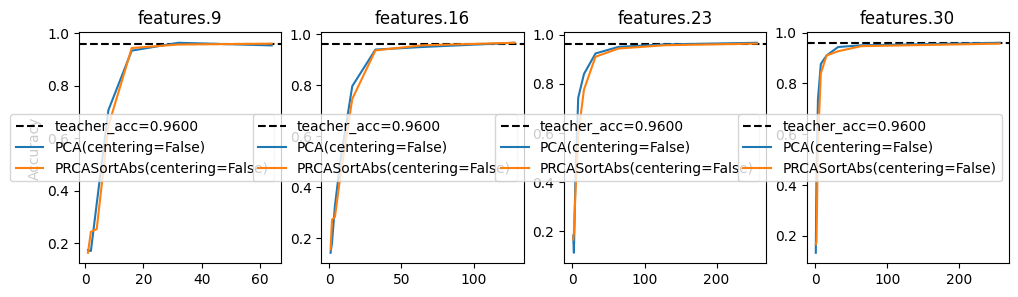

In [22]:
def get_accuracy_layers(
    arr_layers,
    arr_basis_classes,
):

    arr_stats = []

    ncols = len(arr_layers)
    
    plt.figure(figsize=(3*ncols, 3))
    
    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix+1)
        
        plt.axhline(teacher_acc, ls="--", color="black", label=f"teacher_acc={teacher_acc:.4f}")
        plt.title(layer)

        arr_act, arr_ctx = get_act_ctx(
            teacher,
            dataset,
            gamma=GAMMA,
            layer=layer, 
            verbose=False
        )

        for basis_class in arr_basis_classes:
            basis = basis_class(teacher, layer, arr_act, arr_ctx)

            _, d = arr_act.shape
            
            arr_ks = np.power(2, np.arange(np.log2(d // 2) + 1))
    
            df = compute_accuracy_of_basis_at_k(
                teacher, dataset, layer, 
                arr_bases=[basis],
                arr_ks=arr_ks.astype(int).tolist()
            )
    
            plt.plot(df.k, df.acc_val, label=f"{basis}")
            
        if lix == 0:
            plt.ylabel("Accuracy")
        
        plt.legend()

get_accuracy_layers(
    arr_layers=["features.9",  "features.16", "features.23",  "features.30"],
    arr_basis_classes=[PCA, PRCASortAbs]
)

In [23]:
def compute_cascade_accuracy(
    arr_layers,
    arr_dims,
    arr_bases,
    centering
):
    dl_val = datasets.build_dataloader(ds_val, shuffle=False)

    arr_trained_bases = dict()
    print("Training Bases")
    for layer in arr_layers:
        arr_act, arr_ctx = get_act_ctx(
            teacher,
            dataset,
            gamma=GAMMA,
            layer=layer, 
            verbose=False
        )

        for bix, basis_cls in enumerate(arr_bases):
            basis_obj = basis_cls(teacher, layer, arr_act, arr_ctx, centering=centering)
            slug = f"{basis_obj}"

            if slug not in arr_trained_bases:
                arr_trained_bases[slug] = dict()    
                
            arr_trained_bases[slug][layer] = basis_obj

    arr_stats = []
    for basis_slug in tqdm(arr_trained_bases.keys(), desc="computer acc"):
        for seq_dims in arr_dims:
            print(f"[basis_slug={basis_slug}] seq_dims={seq_dims}")

            arr_hooks = []
            try:
                for layer, k in zip(arr_layers, seq_dims):
                    basis = arr_trained_bases[basis_slug][layer]
                    module = utils.interceptor.get_module(teacher, layer)
                    hook_func = basis.get_hook_rank_k_transformation(k, device=device)
                    arr_hooks.append(module.register_forward_hook(hook_func))
                    
                val_acc, _ = metrics.accuracy(
                    teacher,
                    dataloader=dl_val,
                    num_classes=dataset.num_classes,
                    device=device,
                )
            finally:
                for hook in arr_hooks:
                    hook.remove()

            arr_stats.append(dict(
                basis=basis_slug,
                dims=",".join(np.array(seq_dims).astype(str)),
                val_acc=val_acc
            ))

    return pd.DataFrame(arr_stats)

df_cascade = compute_cascade_accuracy(
    arr_layers=["features.9",  "features.16", "features.23",  "features.30"],
    arr_dims=[
        (64, 56, 48, 40),

        (48, 40, 32, 24),

        (40, 32, 24, 16),

        (32, 24, 16, 8),
        
        (24, 16, 8, 4),
    ],
    arr_bases=[
        PCA, 
        PCALookAhead, 
        PRCASortAbs
    ],
    centering=False
)

Training Bases
Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


100%|████████████████████████████████████████████████████████| 122/122 [02:17<00:00,  1.13s/it]


Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


100%|████████████████████████████████████████████████████████| 122/122 [01:50<00:00,  1.10it/s]


Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


...


100%|████████████████████████████████████████████████████████████| 5/5 [02:49<00:00, 34.00s/it]

k=4, epoch=4, acc=0.8400



computer acc:  67%|████████████████████████████              | 2/3 [1:32:53<54:37, 3277.05s/it]

[basis_slug=PRCASortAbs(centering=False)] seq_dims=(64, 56, 48, 40)
[basis_slug=PRCASortAbs(centering=False)] seq_dims=(48, 40, 32, 24)
[basis_slug=PRCASortAbs(centering=False)] seq_dims=(40, 32, 24, 16)
[basis_slug=PRCASortAbs(centering=False)] seq_dims=(32, 24, 16, 8)
[basis_slug=PRCASortAbs(centering=False)] seq_dims=(24, 16, 8, 4)


computer acc: 100%|██████████████████████████████████████████| 3/3 [1:33:03<00:00, 1861.24s/it]


In [24]:
df_cascade

,basis,dims,val_acc
0,PCA(centering=False),"64,56,48,40",0.930000
1,PCA(centering=False),"48,40,32,24",0.903333
2,PCA(centering=False),"40,32,24,16",0.823333
3,PCA(centering=False),"32,24,16,8",0.660000
4,PCA(centering=False),"24,16,8,4",0.450000
5,PCALookAhead(centering=False),"64,56,48,40",0.943333
6,PCALookAhead(centering=False),"48,40,32,24",0.933333
7,PCALookAhead(centering=False),"40,32,24,16",0.926667
8,PCALookAhead(centering=False),"32,24,16,8",0.923333
9,PCALookAhead(centering=False),"24,16,8,4",0.840000


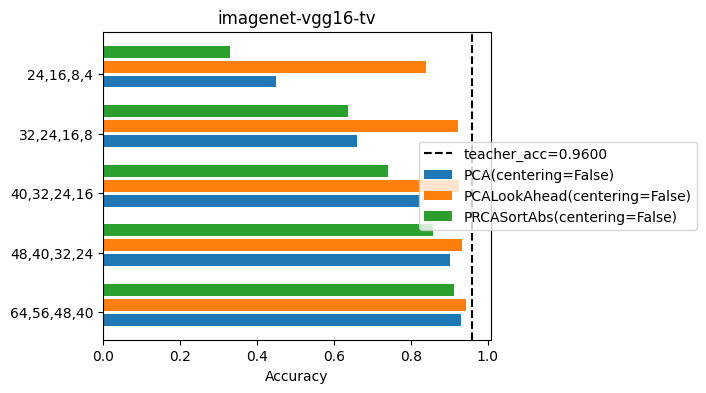

In [25]:
def viz_cascade(df):

    arr_dims = df.dims.unique()
    nsteps = len(arr_dims)

    ticks = np.arange(nsteps) * 4


    plt.figure(figsize=(5, 4))

    plt.title(f"{MODEL_NAME}")
    plt.axvline(teacher_acc, ls="--", color="black", label=f"teacher_acc={teacher_acc:.4f}")
    plt.xlabel("Accuracy")
    for bix, basis in enumerate(df.basis.unique()):
        _df = df[df.basis == basis]
        plt.barh(
            ticks + bix, 
            _df["val_acc"],
            label=basis
        )
    plt.yticks(ticks + 0.5 , arr_dims)
    plt.legend(loc="right",bbox_to_anchor=(1.55, 0.5))
viz_cascade(df_cascade)

Training Bases
Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


100%|████████████████████████████████████████████████████████| 122/122 [02:20<00:00,  1.15s/it]


Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


100%|████████████████████████████████████████████████████████| 122/122 [01:48<00:00,  1.13it/s]


Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


...


100%|████████████████████████████████████████████████████████████| 5/5 [02:49<00:00, 33.94s/it]

k=4, epoch=4, acc=0.6933



computer acc:  67%|████████████████████████████              | 2/3 [1:33:34<55:01, 3301.18s/it]

[basis_slug=PRCASortAbs(centering=True)] seq_dims=(64, 56, 48, 40)
[basis_slug=PRCASortAbs(centering=True)] seq_dims=(48, 40, 32, 24)
[basis_slug=PRCASortAbs(centering=True)] seq_dims=(40, 32, 24, 16)
[basis_slug=PRCASortAbs(centering=True)] seq_dims=(32, 24, 16, 8)
[basis_slug=PRCASortAbs(centering=True)] seq_dims=(24, 16, 8, 4)


computer acc: 100%|██████████████████████████████████████████| 3/3 [1:33:44<00:00, 1874.82s/it]


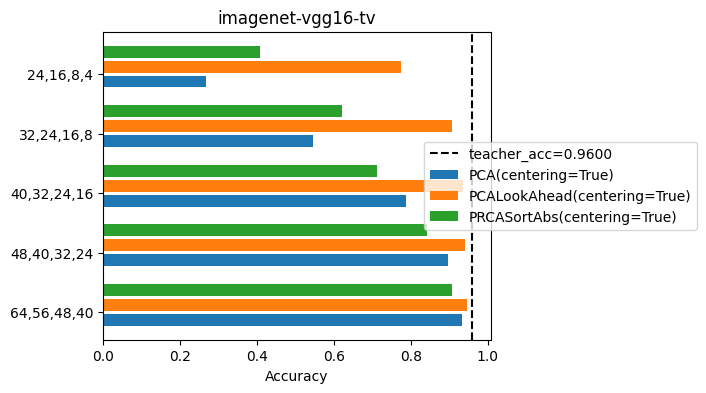

In [26]:
viz_cascade(compute_cascade_accuracy(
    arr_layers=["features.9",  "features.16", "features.23",  "features.30"],
    arr_dims=[
        (64, 56, 48, 40),

        (48, 40, 32, 24),

        (40, 32, 24, 16),

        (32, 24, 16, 8),
        
        (24, 16, 8, 4),
    ],
    arr_bases=[
        PCA, 
        PCALookAhead, 
        PRCASortAbs
    ],
    centering=True
))

In [27]:
print(f"Finished at {datetime.now()}")

Finished at 2024-05-12 17:45:59.137746
